In [ ]:
"""
Quantum Capsule Network — Full Research Validation v4 (QCN-Adaptive)
=====================================================================
CHANGES vs original:
  - All figure backgrounds → WHITE
  - Fig 1: only gradient variance plot, NO horizontal/vertical reference lines
  - Fig 4: Final Expressibility (polar) removed
           S-score + Depth Evolution combined into ONE dual-axis graph
  - Loss convergence: runs until loss < LOSS_CONVERGE_THR or EPOCHS_QFIM_MAX
  - MAX_DEPTH = 10  (adaptive layers grow up to 8-10)

FIX (loss graph smoothing):
  - Batch size 16 → 64  (কম noise)
  - Learning rate decay যোগ করা হয়েছে
  - Plot-এ moving average smoothing যোগ করা হয়েছে

PLOT CHANGES (v4.3):
  - Fig1: title removed, fit lines removed, vertical error bars removed
  - Fig2: right panel removed, left panel title removed
  - Fig3: split into 2 separate figures, titles removed
  - Fig4 left: title removed, X=Depth Y=S-score scatter
  - Fig4 right: title removed, threshold line removed, label cleaned
"""

import numpy as _np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import warnings, os, csv, time as _time, datetime
warnings.filterwarnings('ignore')

import pennylane as qml
from pennylane import numpy as pnp
from scipy.linalg import eigvalsh
from scipy.stats import ks_2samp
from scipy.optimize import curve_fit
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import normalize

_np.random.seed(42)
pnp.random.seed(42)

# ════════════════════════════════════════════════════════════════════════════
# Output directory + CSV helpers
# ════════════════════════════════════════════════════════════════════════════
BASE_DIR = r"C:\Users\User\Downloads\barren pleatau mitigation\barren_plateau_output"
os.makedirs(BASE_DIR, exist_ok=True)

_TS      = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
_TIMINGS = {}

def _csv_path(name):
    return os.path.join(BASE_DIR, f"{name}_{_TS}.csv")

def _write_csv(path, header, rows):
    with open(path, 'w', newline='', encoding='utf-8') as f:
        w = csv.writer(f)
        w.writerow(header)
        w.writerows(rows)
    kb = os.path.getsize(path) // 1024
    print(f"  ✓  CSV → {os.path.basename(path)}  ({kb} KB)")

def _tick(label):
    _TIMINGS[label] = _time.perf_counter()

def _tock(label):
    elapsed = _time.perf_counter() - _TIMINGS[label]
    _TIMINGS[label] = elapsed
    print(f"  ⏱  [{label}] finished in {elapsed:.1f}s  ({elapsed/60:.2f} min)")

# ════════════════════════════════════════════════════════════════════════════
# Style — WHITE background
# ════════════════════════════════════════════════════════════════════════════
BG      = 'white'
AX_BG   = 'white'
AX_EDGE = '#cccccc'
TICK_C  = '#444444'
TXT_C   = '#111111'
GRID_C  = '#e8e8e8'

plt.rcParams.update({
    'figure.facecolor':  BG,
    'axes.facecolor':    AX_BG,
    'axes.edgecolor':    AX_EDGE,
    'axes.labelcolor':   TXT_C,
    'xtick.color':       TICK_C,
    'ytick.color':       TICK_C,
    'grid.color':        GRID_C,
    'grid.linewidth':    0.8,
    'text.color':        TXT_C,
    'legend.facecolor':  'white',
    'legend.edgecolor':  AX_EDGE,
    'legend.fontsize':   9,
    'axes.titlesize':    11,
    'axes.labelsize':    10,
    'font.family':       'monospace',
    'lines.linewidth':   2.0,
})

# ════════════════════════════════════════════════════════════════════════════
# Hyperparameters
# ════════════════════════════════════════════════════════════════════════════
QUBIT_RANGES   = [4,6,  8,10, 12, 14, 16, 18]
CAP_SIZES      = [2, 3, 4, 6, 9]
CAP_COLORS     = {2: '#1a7abf', 3: '#e07b00', 4: '#1e8c45', 6: '#9b2dca', 9: '#c0392b'}
C_GLOBAL       = '#2c2c2c'
CAP_PAL        = ['#1a7abf', '#c0392b', '#e07b00', '#1e8c45']

FIXED_N        = 12
N_SEEDS        = 5
N_LAYERS       = 2
N_STEPS        = 4
DEPTH_MAX      = 6
N_ENT_SEEDS    = 5
N_HESS_SEEDS   = 3
K_HESS         = 4

MAX_DEPTH      = 10

QFIM_INTERVAL  = 5
S_PLATEAU_THR  = 0.30
QFIM_N         = 12
QFIM_N_CAPS    = 4
QFIM_CAP_SIZE  = 3

EPOCHS_QFIM_MAX    = 300
LOSS_CONVERGE_THR  = 0.15

ADAPT_WARMUP_EPOCHS = 5

# ════════════════════════════════════════════════════════════════════════════
# [FIX] Smoothing helper function
# ════════════════════════════════════════════════════════════════════════════
def smooth_loss(arr, window=15):
    """Moving average smoothing — traditional loss curve এর মতো দেখায়"""
    if len(arr) < window:
        return _np.array(arr)
    kernel = _np.ones(window) / window
    return _np.convolve(arr, kernel, mode='valid')

def smooth_epochs(n_epochs, window=15):
    """Smoothed epoch axis (same length as smooth_loss output)"""
    if n_epochs < window:
        return _np.arange(n_epochs)
    return _np.arange(window - 1, n_epochs)

print('=' * 70)
print('  QUANTUM CAPSULE NETWORK — FULL RESEARCH VALIDATION v4.3 (FIXED PLOTS)')
print('=' * 70)
print(f'  Qubits       : {QUBIT_RANGES}')
print(f'  Cap sizes    : {CAP_SIZES}')
print(f'  Initial depth: {N_LAYERS}  Max depth: {MAX_DEPTH}')
print(f'  GV seeds     : {N_SEEDS}   Entropy seeds: {N_ENT_SEEDS}')
print(f'  Hessian      : {N_HESS_SEEDS} seeds')
print(f'  QFIM epochs  : up to {EPOCHS_QFIM_MAX}  (stop when loss < {LOSS_CONVERGE_THR})')
print(f'  Output dir   : {BASE_DIR}')
print('=' * 70)


# ════════════════════════════════════════════════════════════════════════════
# Circuit builders
# ════════════════════════════════════════════════════════════════════════════

def build_global_circuit(n, dev, depth=N_LAYERS):
    n_p = depth * n * 2

    @qml.qnode(dev, diff_method='best')
    def circuit(params, x):
        x_vals = [float(x[i]) for i in range(n)]
        p = params.reshape(depth, n, 2)
        for i in range(n):
            qml.RY(x_vals[i], wires=i)
        for layer in range(depth):
            for i in range(n):
                qml.RY(p[layer, i, 0], wires=i)
            for i in range(n - 1):
                qml.CNOT(wires=[i, i + 1])
            qml.CNOT(wires=[0, n - 1])
            for i in range(n):
                qml.RZ(p[layer, i, 1], wires=i)
        return qml.expval(qml.PauliZ(0) @ qml.PauliZ(n - 1))

    return circuit, n_p


def build_adaptive_qcn_circuit(n, n_caps, cap_size, depths, dev):
    offsets = [0]
    for c in range(n_caps):
        offsets.append(offsets[-1] + depths[c] * cap_size * 4)
    total_params = offsets[-1]
    max_d = max(depths)

    @qml.qnode(dev, diff_method='best')
    def circuit(params, x):
        for i in range(n):
            qml.Hadamard(wires=i)

        for layer in range(max_d):
            for c in range(n_caps):
                if layer >= depths[c]:
                    continue
                w  = list(range(c * cap_size, (c + 1) * cap_size))
                cp = params[offsets[c]: offsets[c + 1]].reshape(
                         depths[c], cap_size, 4)
                xc = [float(x[c * cap_size + j]) for j in range(cap_size)]

                for j, wire in enumerate(w):
                    qml.RY(xc[j] * cp[layer, j, 3], wires=wire)
                for j, wire in enumerate(w):
                    qml.Rot(cp[layer, j, 0],
                            cp[layer, j, 1],
                            cp[layer, j, 2], wires=wire)
                if layer % 2 == 0:
                    for j in range(len(w) - 1):
                        qml.CNOT(wires=[w[j], w[j + 1]])
                    if len(w) > 2:
                        qml.CNOT(wires=[w[-1], w[0]])

            if layer % 2 == 0:
                ic_offset = (layer // 2) % 2
                for c in range(ic_offset, n_caps - 1, 2):
                    if layer < depths[c] and layer < depths[c + 1]:
                        boundary_a = (c + 1) * cap_size - 1
                        boundary_b = (c + 1) * cap_size
                        qml.CNOT(wires=[boundary_a, boundary_b])

        return qml.math.stack([
            qml.expval(qml.PauliZ(c * cap_size)) for c in range(n_caps)
        ])

    return circuit, total_params, offsets


# ════════════════════════════════════════════════════════════════════════════
# AdaptiveQCN
# ════════════════════════════════════════════════════════════════════════════

def _ppc(depth, cap_size):
    return depth * cap_size * 4


def _init_cap_params(depth, cap_size, rng=None):
    if rng is None:
        rng = _np.random
    p       = rng.uniform(0, 0.5, _ppc(depth, cap_size))
    p[3::4] = rng.uniform(0.8, 1.2, len(p) // 4)
    return p.astype(float)


def _compute_qfim_score(cap_params_np, depth, x_cap_np, cap_size):
    dev       = qml.device('default.qubit', wires=cap_size)
    flat_size = _ppc(depth, cap_size)
    x_arr_np  = _np.array(x_cap_np, dtype=float)

    @qml.qnode(dev)
    def cap_state(p_flat):
        p = p_flat.reshape(depth, cap_size, 4)
        for i in range(cap_size):
            qml.Hadamard(wires=i)
        for layer in range(depth):
            for i in range(cap_size):
                qml.RY(float(x_arr_np[i]) * p[layer, i, 3], wires=i)
            for i in range(cap_size):
                qml.Rot(p[layer, i, 0], p[layer, i, 1], p[layer, i, 2], wires=i)
            if layer % 2 == 0:
                for i in range(cap_size - 1):
                    qml.CNOT(wires=[i, i + 1])
                if cap_size > 2:
                    qml.CNOT(wires=[cap_size - 1, 0])
        return qml.state()

    try:
        mt_fn  = qml.metric_tensor(cap_state, approx='block-diag')
        p_flat = pnp.array(cap_params_np.flatten(), requires_grad=True)
        qfim   = mt_fn(p_flat).reshape(flat_size, flat_size)
        eigs   = _np.clip(_np.abs(_np.linalg.eigvalsh(_np.array(qfim))), 1e-8, 1e4)
        d_eff  = float((_np.sum(eigs) ** 2) / (_np.sum(eigs ** 2) + 1e-12))
        kappa  = float(_np.max(eigs) / (_np.min(eigs) + 1e-8))
        s      = d_eff / (_np.log10(kappa + 1) + 1e-10)
        return float(s), float(kappa), float(d_eff)
    except Exception:
        return 0.0, 1.0, 0.0


class AdaptiveQCN:
    def __init__(self, n, n_caps, cap_size, dev,
                 init_depth=N_LAYERS, max_depth=MAX_DEPTH,
                 plateau_thr=S_PLATEAU_THR, seed=0):
        self.n           = n
        self.n_caps      = n_caps
        self.cap_size    = cap_size
        self.dev         = dev
        self.max_depth   = max_depth
        self.plateau_thr = plateau_thr

        rng              = _np.random.RandomState(seed)
        self.depths      = [init_depth] * n_caps
        self._cap_params = [_init_cap_params(init_depth, cap_size, rng)
                            for _ in range(n_caps)]
        self._s_window   = [[] for _ in range(n_caps)]
        self.s_records   = []
        self.growth_log  = []
        self._rebuild_params()

    def _rebuild_params(self):
        flat          = _np.concatenate(self._cap_params)
        self.params   = pnp.array(flat, requires_grad=True)
        _, self.n_params, self.offsets = build_adaptive_qcn_circuit(
            self.n, self.n_caps, self.cap_size, self.depths, self.dev)

    def _sync_cap_params_from_flat(self, flat_np):
        for c in range(self.n_caps):
            sz = _ppc(self.depths[c], self.cap_size)
            self._cap_params[c] = flat_np[
                self.offsets[c]: self.offsets[c] + sz].copy()

    def get_circuit(self):
        return build_adaptive_qcn_circuit(
            self.n, self.n_caps, self.cap_size, self.depths, self.dev)

    def update_params(self, new_flat):
        new_np = _np.array(new_flat)
        self._sync_cap_params_from_flat(new_np)
        self.params = pnp.array(new_np, requires_grad=True)

    def maybe_grow(self, x_sample_np, epoch, verbose=False):
        grew = False
        for c in range(self.n_caps):
            x_cap = x_sample_np[c * self.cap_size: (c + 1) * self.cap_size]
            s, _, _ = _compute_qfim_score(
                self._cap_params[c], self.depths[c], x_cap, self.cap_size)
            self.s_records.append((epoch, c, s))
            self._s_window[c].append(s)

            if self.depths[c] >= self.max_depth:
                continue
            sw = self._s_window[c]
            if len(sw) >= 4:
                dS = (sw[-1] - sw[-4]) / 4
                if abs(dS) < self.plateau_thr:
                    old_d = self.depths[c]
                    self.depths[c] += 1
                    rng     = _np.random.RandomState(epoch * 100 + c)
                    new_lyr = rng.uniform(0, 0.1, self.cap_size * 4)
                    new_lyr[3::4] = rng.uniform(0.9, 1.1, self.cap_size)
                    self._cap_params[c] = _np.concatenate(
                        [self._cap_params[c], new_lyr])
                    self.growth_log.append((epoch, c, old_d, self.depths[c]))
                    grew = True
                    if verbose:
                        print(f'    [AdaptiveQCN] Ep {epoch:3d} | '
                              f'Cap{c} {old_d}→{self.depths[c]} '
                              f'(|ΔS|={abs(dS):.3f})')
        if grew:
            self._rebuild_params()
        return grew

    def final_s_scores(self, x_sample_np):
        scores = []
        for c in range(self.n_caps):
            x_cap = x_sample_np[c * self.cap_size: (c + 1) * self.cap_size]
            s, _, _ = _compute_qfim_score(
                self._cap_params[c], self.depths[c], x_cap, self.cap_size)
            scores.append(s)
        return scores


# ════════════════════════════════════════════════════════════════════════════
# Helper utilities
# ════════════════════════════════════════════════════════════════════════════

def exp_decay(n, A, alpha):
    return A * _np.exp(-alpha * _np.array(n, dtype=float))


def safe_fit(xs, ys, label):
    try:
        popt, _ = curve_fit(exp_decay, xs, ys, p0=[0.5, 0.3], maxfev=10000,
                            bounds=([0, 1e-4], [1e3, 10]))
        print(f'    Fit {label:<18}: A={popt[0]:.5f}  α={popt[1]:.5f}')
        return popt
    except Exception as e:
        print(f'    Fit {label:<18}: FAILED — {e}')
        return None


def savefig(name):
    path = os.path.join(BASE_DIR, name)
    plt.savefig(path, dpi=200, bbox_inches='tight',
                facecolor='white', edgecolor='none')
    plt.close()
    kb = os.path.getsize(path) // 1024
    print(f'  ✓  Figure → {name}  ({kb} KB)')


# ════════════════════════════════════════════════════════════════════════════
# [1] Gradient Variance Scaling
# ════════════════════════════════════════════════════════════════════════════

def grad_var_single(n, n_caps, cap_size, model, seed=0):
    pnp.random.seed(seed)
    _np.random.seed(seed)
    dev = qml.device('lightning.qubit', wires=n)

    if model == 'global':
        circ, n_p = build_global_circuit(n, dev)

        def cost(p, x):
            return circ(p, x) ** 2

        p   = pnp.random.uniform(0, 2 * _np.pi, n_p, requires_grad=True)
        x   = pnp.array(_np.random.uniform(0, _np.pi, n), requires_grad=False)
        gvs = []
        for _ in range(N_STEPS):
            g = qml.grad(cost, argnums=0)(p, x)
            gvs.append(float(_np.var(_np.array(g).flatten())))
        raw  = float(_np.mean(gvs))
        norm = raw / n_p
        return raw, norm, n_p

    else:
        rng   = _np.random.RandomState(seed)
        x_np  = rng.uniform(0, _np.pi, n)
        x_pnp = pnp.array(x_np, requires_grad=False)

        aqcn  = AdaptiveQCN(n, n_caps, cap_size, dev,
                            init_depth=N_LAYERS, seed=seed)

        ep_per_layer = max(1, ADAPT_WARMUP_EPOCHS // N_LAYERS)
        params_full  = _np.array(aqcn.params).copy()
        act_per_cap  = cap_size * 4

        for d_stage in range(N_LAYERS):
            n_act = (d_stage + 1) * act_per_cap
            n_frz = (N_LAYERS - d_stage - 1) * act_per_cap

            active_parts = []
            frozen_parts = []
            for c in range(n_caps):
                base = aqcn.offsets[c]
                active_parts.append(params_full[base: base + n_act])
                if n_frz > 0:
                    frozen_parts.append(params_full[base + n_act:
                                                     base + n_act + n_frz])

            p_active = pnp.array(
                _np.concatenate(active_parts), requires_grad=True)
            p_frozen = pnp.array(
                _np.concatenate(frozen_parts) if frozen_parts else _np.array([]),
                requires_grad=False)

            opt   = qml.AdamOptimizer(stepsize=0.015)
            n_ep  = (ep_per_layer if d_stage < N_LAYERS - 1
                     else ADAPT_WARMUP_EPOCHS - d_stage * ep_per_layer)
            n_ep  = max(1, n_ep)
            circ, _, _ = aqcn.get_circuit()

            for ep in range(n_ep):
                def cost_warmup(pa, c=circ, xx=x_pnp,
                                pf=p_frozen,
                                nc=n_caps, na=n_act, nf=n_frz):
                    chunks = []
                    for ci in range(nc):
                        chunks.append(pa[ci * na: (ci + 1) * na])
                        if nf > 0:
                            chunks.append(pf[ci * nf: (ci + 1) * nf])
                    pp = pnp.concatenate(chunks)
                    return pnp.sum(c(pp, xx) ** 2)

                p_active, _ = opt.step_and_cost(cost_warmup, p_active)

            p_act_np = _np.array(p_active)
            p_frz_np = _np.array(p_frozen)
            for c in range(n_caps):
                base = aqcn.offsets[c]
                params_full[base: base + n_act] = p_act_np[c * n_act:
                                                             (c+1) * n_act]
                if n_frz > 0:
                    params_full[base + n_act: base + n_act + n_frz] = \
                        p_frz_np[c * n_frz: (c+1) * n_frz]

            aqcn.update_params(params_full)
            ep_global = (d_stage + 1) * ep_per_layer
            if ep_global % QFIM_INTERVAL == 0:
                aqcn.maybe_grow(x_np, ep_global, verbose=False)

        circ_fn, _, _ = aqcn.get_circuit()

        def cost_gv(p, xx=x_pnp, c=circ_fn):
            return pnp.sum(c(p, xx) ** 2)

        gvs = []
        for _ in range(N_STEPS):
            g = qml.grad(cost_gv, argnums=0)(aqcn.params)
            gvs.append(float(_np.var(_np.array(g).flatten())))
        raw  = float(_np.mean(gvs))
        norm = raw / aqcn.n_params
        return raw, norm, aqcn.n_params


# ── Run Section 1 ─────────────────────────────────────────────────────────────
print('\n[1/5] Gradient Variance Scaling ...')
_tick('1_GradVar')

gv_global = {'n': [], 'mean': [], 'std': [], 'norm': []}
gv_caps   = {cs: {'n': [], 'mean': [], 'std': [], 'norm': []}
             for cs in CAP_SIZES}

for n in QUBIT_RANGES:
    print(f'  n={n:<3}', end='  |  ')
    raws = [grad_var_single(n, 1, n, 'global', seed=s)[0] for s in range(N_SEEDS)]
    gv_global['n'].append(n)
    gv_global['mean'].append(_np.mean(raws))
    gv_global['std'].append(_np.std(raws))
    gv_global['norm'].append(_np.mean(raws) / n)
    print(f'global={_np.mean(raws):.2e}', end='  ')

    for cs in CAP_SIZES:
        if n % cs != 0 or ( n % cs ==0 and n//cs==1):
            continue
        nc = n // cs
        rs, ns_ = [], []
        for s in range(N_SEEDS):
            r, nm, _ = grad_var_single(n, nc, cs, 'qcn', seed=s)
            rs.append(r)
            ns_.append(nm)
        gv_caps[cs]['n'].append(n)
        gv_caps[cs]['mean'].append(_np.mean(rs))
        gv_caps[cs]['std'].append(_np.std(rs))
        gv_caps[cs]['norm'].append(_np.mean(ns_))
        print(f'cs={cs}:{_np.mean(rs):.2e}', end='  ')
    print()

print()
decay_fits      = {}
decay_fits_norm = {}
decay_fits['global']      = safe_fit(gv_global['n'], gv_global['mean'],  'global(raw)')
decay_fits_norm['global'] = safe_fit(gv_global['n'], gv_global['norm'],  'global(norm)')
for cs in CAP_SIZES:
    d = gv_caps[cs]
    if len(d['n']) < 3:
        decay_fits[cs] = decay_fits_norm[cs] = None
        print(f'    Fit cs={cs}(raw)       : skipped (< 3 points)')
        continue
    decay_fits[cs]      = safe_fit(d['n'], d['mean'], f'cs={cs}(raw)')
    decay_fits_norm[cs] = safe_fit(d['n'], d['norm'], f'cs={cs}(norm)')

_tock('1_GradVar')

# ── Save Section 1 CSV ────────────────────────────────────────────────────────
_rows_gv = []
for i, n in enumerate(gv_global['n']):
    a_raw  = decay_fits['global'][1]      if decay_fits.get('global')      is not None else ''
    a_norm = decay_fits_norm['global'][1] if decay_fits_norm.get('global') is not None else ''
    _rows_gv.append([n, 'global',
                     gv_global['mean'][i], gv_global['std'][i],
                     gv_global['norm'][i], a_raw, a_norm])

for cs in CAP_SIZES:
    d = gv_caps[cs]
    for i, n in enumerate(d['n']):
        a_raw  = decay_fits[cs][1]      if decay_fits.get(cs)      is not None else ''
        a_norm = decay_fits_norm[cs][1] if decay_fits_norm.get(cs) is not None else ''
        _rows_gv.append([n, f'qcn_cs{cs}',
                         d['mean'][i], d['std'][i], d['norm'][i],
                         a_raw, a_norm])

_write_csv(_csv_path('01_gradient_variance'),
           ['n_qubits', 'model', 'grad_var_mean', 'grad_var_std',
            'grad_var_norm', 'alpha_exp_fit_raw', 'alpha_exp_fit_norm'],
           _rows_gv)


# ════════════════════════════════════════════════════════════════════════════
# [2] Entanglement Entropy vs Depth
# ════════════════════════════════════════════════════════════════════════════

def entropy_from_state(rho):
    evs = _np.real(_np.linalg.eigvalsh(_np.array(rho)))
    evs = _np.abs(evs)
    evs = evs[evs > 1e-12]
    evs /= evs.sum()
    return float(-_np.sum(evs * _np.log2(evs + 1e-15)))


def entropy_global_at_depth(n, depth, n_seeds=15):
    dev   = qml.device('default.qubit', wires=n)
    half  = n // 2
    sub_w = list(range(half))
    results = []
    for seed in range(n_seeds):
        rng = _np.random.RandomState(seed)
        p   = rng.uniform(0.3, 2.5, depth * n * 2)

        @qml.qnode(dev)
        def circ(params, _d=depth, _n=n):
            for i in range(_n):
                qml.Hadamard(wires=i)
            for d in range(_d):
                for i in range(_n):
                    qml.RY(params[d * _n * 2 + i],      wires=i)
                    qml.RZ(params[d * _n * 2 + _n + i], wires=i)
                for i in range(_n - 1):
                    qml.CNOT(wires=[i, i + 1])
                qml.CNOT(wires=[0, _n - 1])
            return qml.density_matrix(wires=sub_w)

        results.append(entropy_from_state(circ(_np.array(p))))
    return float(_np.mean(results)), float(_np.std(results))


# ════════════════════════════════════════════════════════════════════════════
# [2] Entanglement Entropy — FIXED (random params instead of trained)
# ════════════════════════════════════════════════════════════════════════════

def entropy_adaptive_qcn_at_depth(n, n_caps, cap_size, depth, n_seeds=15):
    """
    Random (Haar-like) parameter sampling দিয়ে entropy মাপা।
    
    কেন trained params ব্যবহার করা উচিত না:
      - Cost = Σ(output²) minimize করতে গিয়ে optimizer state-কে
        product state-এ collapse করে → entropy ≈ 0
      - এটা circuit architecture-এর property না, training dynamics-এর artifact
    
    কেন random params সঠিক:
      - Architectural entanglement CAPACITY মাপা হচ্ছে
      - CNOT structure কতটুকু entanglement generate করতে পারে সেটা দেখা হচ্ছে
      - Area Law vs Volume Law comparison theoretically valid হয়
    """
    half  = n // 2
    sub_w = list(range(half))
    results = []

    for seed in range(n_seeds):
        rng    = _np.random.RandomState(seed)
        x_np   = rng.uniform(0, _np.pi, n)

        offs = [0]
        for c in range(n_caps):
            offs.append(offs[-1] + depth * cap_size * 4)
        total_params = offs[-1]

        # Haar-like random initialization — full [0, 2π] range
        params_np = rng.uniform(0, 2 * _np.pi, total_params)
        # data-encoding weights (index 3::4) realistic range রাখা
        params_np[3::4] = rng.uniform(0.8, 1.2, len(params_np[3::4]))

        dev_dm = qml.device('default.qubit', wires=n)

        @qml.qnode(dev_dm)
        def circ_dm(params, _depth=depth, _offs=offs):
            for i in range(n):
                qml.Hadamard(wires=i)
            for layer in range(_depth):
                for c in range(n_caps):
                    w  = list(range(c * cap_size, (c + 1) * cap_size))
                    cp = params[_offs[c]: _offs[c+1]].reshape(_depth, cap_size, 4)
                    xc = [float(x_np[c * cap_size + j]) for j in range(cap_size)]
                    for j, wire in enumerate(w):
                        qml.RY(xc[j] * cp[layer, j, 3], wires=wire)
                    for j, wire in enumerate(w):
                        qml.Rot(cp[layer, j, 0],
                                cp[layer, j, 1],
                                cp[layer, j, 2], wires=wire)
                    if layer % 2 == 0:
                        for j in range(len(w) - 1):
                            qml.CNOT(wires=[w[j], w[j + 1]])
                        if len(w) > 2:
                            qml.CNOT(wires=[w[-1], w[0]])
                if layer % 2 == 0:
                    ic_offset = (layer // 2) % 2
                    for c in range(ic_offset, n_caps - 1, 2):
                        if layer < depth:
                            qml.CNOT(wires=[(c + 1) * cap_size - 1,
                                            (c + 1) * cap_size])
            return qml.density_matrix(wires=sub_w)

        results.append(entropy_from_state(circ_dm(params_np)))

    return float(_np.mean(results)), float(_np.std(results))

# ── Run Section 2 ─────────────────────────────────────────────────────────────
print('\n[2/5] Entanglement Entropy (n=12, depth-proxy 1-6) ...')
_tick('2_Entropy')

depths_e = list(range(1, DEPTH_MAX + 1))
S_global = {'mean': [], 'std': []}
S_caps   = {cs: {'mean': [], 'std': []}
            for cs in CAP_SIZES if FIXED_N % cs == 0}
valid_cs = list(S_caps.keys())

for d in depths_e:
    m, s = entropy_global_at_depth(FIXED_N, d, N_ENT_SEEDS)
    S_global['mean'].append(m)
    S_global['std'].append(s)
    for cs in S_caps:
        nc        = FIXED_N // cs
        warmup_ep = d * QFIM_INTERVAL
        m, s = entropy_adaptive_qcn_at_depth(
            FIXED_N, nc, cs, d, N_ENT_SEEDS)
        S_caps[cs]['mean'].append(m)
        S_caps[cs]['std'].append(s)
    print(f'  d≈{d}  global={S_global["mean"][-1]:.3f}  '
          + '  '.join(f'cs={cs}:{S_caps[cs]["mean"][-1]:.3f}'
                      for cs in S_caps))

_tock('2_Entropy')

# ── Save Section 2 CSV ────────────────────────────────────────────────────────
_rows_ent = []
for di, d in enumerate(depths_e):
    _rows_ent.append([d, 'global', FIXED_N, 1,
                      S_global['mean'][di], S_global['std'][di]])
    for cs in valid_cs:
        _rows_ent.append([d, f'qcn_cs{cs}', FIXED_N, FIXED_N // cs,
                          S_caps[cs]['mean'][di], S_caps[cs]['std'][di]])

_write_csv(_csv_path('02_entanglement_entropy'),
           ['depth_proxy', 'model', 'n_qubits', 'n_caps',
            'entropy_mean_bits', 'entropy_std_bits'],
           _rows_ent)


# ════════════════════════════════════════════════════════════════════════════
# [3] Hessian KS-Statistic Scaling
# ════════════════════════════════════════════════════════════════════════════

def hessian_eigs_adaptive(n, n_caps, cap_size, n_seeds=6):
    eigs_all = []
    for seed in range(n_seeds):
        _np.random.seed(seed * 100 + n)
        pnp.random.seed(seed * 100 + n)
        rng   = _np.random.RandomState(seed * 100 + n)
        x_np  = rng.uniform(0, _np.pi, n)
        x_pnp = pnp.array(x_np, requires_grad=False)

        dev  = qml.device('lightning.qubit', wires=n)
        aqcn = AdaptiveQCN(n, n_caps, cap_size, dev,
                           init_depth=N_LAYERS, seed=seed)
        opt  = qml.AdamOptimizer(stepsize=0.015)

        for ep in range(ADAPT_WARMUP_EPOCHS):
            circ_fn, _, _ = aqcn.get_circuit()

            def cost_h(pp, c=circ_fn, xx=x_pnp):
                return pnp.sum(c(pp, xx) ** 2)

            new_p, _ = opt.step_and_cost(cost_h, aqcn.params)
            aqcn.update_params(_np.array(new_p))
            if ep % QFIM_INTERVAL == 0:
                grew = aqcn.maybe_grow(x_np, ep, verbose=False)
                if grew:
                    opt = qml.AdamOptimizer(stepsize=0.015)

        k       = min(aqcn.n_params, K_HESS)
        eps     = 1e-4
        circ_fn, _, _ = aqcn.get_circuit()

        def cost_fn(pp, c=circ_fn, xx=x_pnp):
            return pnp.sum(c(pp, xx) ** 2)

        H = _np.zeros((k, k))
        for i in range(k):
            for j in range(k):
                pp_arr = _np.array(aqcn.params)
                pp_arr[i] += eps; pp_arr[j] += eps
                pp = pnp.array(pp_arr); v_pp = float(cost_fn(pp))
                pp_arr[j] -= 2 * eps
                pp = pnp.array(pp_arr); v_pm = float(cost_fn(pp))
                pp_arr[i] -= 2 * eps
                pp = pnp.array(pp_arr); v_mm = float(cost_fn(pp))
                pp_arr[j] += 2 * eps
                pp = pnp.array(pp_arr); v_mp = float(cost_fn(pp))
                H[i, j] = (v_pp - v_pm - v_mp + v_mm) / (4 * eps ** 2)
        eigs_all.extend(_np.abs(eigvalsh(H)).tolist())
    return _np.array(eigs_all)


def hessian_eigs_global(n, n_seeds=6):
    eigs_all = []
    dev = qml.device('lightning.qubit', wires=n)
    k   = min(n, K_HESS)
    eps = 1e-4
    for seed in range(n_seeds):
        pnp.random.seed(seed * 100 + n)
        x    = pnp.array(_np.random.uniform(0, _np.pi, n), requires_grad=False)
        circ, n_p = build_global_circuit(n, dev)

        def cost(p, x=x):
            return circ(p, x) ** 2

        p = pnp.random.uniform(0, 2 * _np.pi, n_p, requires_grad=True)
        H = _np.zeros((k, k))
        for i in range(k):
            for j in range(k):
                pp = p.copy(); pp[i] += eps; pp[j] += eps
                pm = p.copy(); pm[i] += eps; pm[j] -= eps
                mp = p.copy(); mp[i] -= eps; mp[j] += eps
                mm = p.copy(); mm[i] -= eps; mm[j] -= eps
                H[i, j] = (cost(pp) - cost(pm) - cost(mp) + cost(mm)) / (4 * eps ** 2)
        eigs_all.extend(_np.abs(eigvalsh(H)).tolist())
    return _np.array(eigs_all)


# ── Run Section 3 ─────────────────────────────────────────────────────────────
print('\n[3/5] Hessian KS-Statistic Scaling ...')
_tick('3_HessianKS')

ks_table = {cs: {'n': [], 'stat': [], 'pval': []} for cs in CAP_SIZES}
for n in QUBIT_RANGES:
    print(f'  n={n:<3}', end='  |  ')
    eigs_g = hessian_eigs_global(n, N_HESS_SEEDS)
    for cs in CAP_SIZES:
        if n % cs != 0:
            continue
        nc         = n // cs
        eigs_c     = hessian_eigs_adaptive(n, nc, cs, N_HESS_SEEDS)
        stat, pval = ks_2samp(eigs_g, eigs_c)
        ks_table[cs]['n'].append(n)
        ks_table[cs]['stat'].append(stat)
        ks_table[cs]['pval'].append(pval)
        print(f'cs={cs} D={stat:.3f}(p={pval:.3f})', end='  ')
    print()

_tock('3_HessianKS')

# ── Save Section 3 CSV ────────────────────────────────────────────────────────
_rows_ks = []
for cs in CAP_SIZES:
    d = ks_table[cs]
    for i, n in enumerate(d['n']):
        pval = d['pval'][i]
        sig  = ('***' if pval < 0.001 else '**' if pval < 0.01
                else '*' if pval < 0.05 else 'ns')
        _rows_ks.append([n, f'qcn_cs{cs}', d['stat'][i], pval, sig])

_write_csv(_csv_path('03_hessian_ks_stat'),
           ['n_qubits', 'model', 'ks_stat_D', 'ks_pval', 'significance'],
           _rows_ks)


# ════════════════════════════════════════════════════════════════════════════
# [4] QFIM Adaptive Depth vs Matched-Depth Baseline
# ════════════════════════════════════════════════════════════════════════════

# ════════════════════════════════════════════════════════════════════════════
# [4] QFIM Adaptive Depth vs Matched-Depth Baseline
#     CHANGED: run until loss < LOSS_CONVERGE_THR or EPOCHS_QFIM_MAX
# ════════════════════════════════════════════════════════════════════════════

def run_qfim_training(n_caps, cap_size, adaptive=True,
                      fixed_depth=2, label='adaptive'):
    n = n_caps * cap_size
    X, y            = load_digits(n_class=2, return_X_y=True)
    X               = normalize(X, norm='l2')
    Xtr, _, ytr, _  = train_test_split(X, y, test_size=0.3, random_state=42)
    X_train         = Xtr[:, :n] * _np.pi
    y_train         = (2 * ytr - 1).astype(float)
    x_sample        = X_train[0]

    dev = qml.device('lightning.qubit', wires=n)
    vn  = pnp.array(_np.ones(n_caps) / n_caps)
    opt = qml.AdamOptimizer(stepsize=0.015)

    if adaptive:
        aqcn = AdaptiveQCN(n, n_caps, cap_size, dev,
                           init_depth=1, max_depth=MAX_DEPTH,
                           plateau_thr=S_PLATEAU_THR, seed=0)
    else:
        aqcn = AdaptiveQCN(n, n_caps, cap_size, dev,
                           init_depth=fixed_depth, max_depth=fixed_depth,
                           plateau_thr=S_PLATEAU_THR, seed=0)

    depth_history = []
    loss_log      = []

    for epoch in range(EPOCHS_QFIM_MAX):
        circ_fn, _, _ = aqcn.get_circuit()

        def cost_fn(p):
            idx   = _np.random.choice(len(X_train), 16, replace=False)
            total = pnp.array(0.0)
            for xi, yt in zip(X_train[idx], y_train[idx]):
                xi_pnp = pnp.array(xi, requires_grad=False)
                pred   = pnp.sum(vn * circ_fn(p, xi_pnp))
                total  = total + (pred - yt) ** 2
            return total / 16

        new_p, loss_val = opt.step_and_cost(cost_fn, aqcn.params)
        aqcn.update_params(_np.array(new_p))
        loss_log.append(float(loss_val))
        depth_history.append(list(aqcn.depths))

        if epoch % QFIM_INTERVAL == 0 and adaptive:
            grew = aqcn.maybe_grow(x_sample, epoch, verbose=True)
            if grew:
                opt = qml.AdamOptimizer(stepsize=0.015)

        if (epoch + 1) % 20 == 0:
            print(f'    [{label}] Ep {epoch+1:3d} | '
                  f'depths={aqcn.depths} | loss={float(loss_val):.4f}')

        # ── Early stop when converged ──────────────────────────────────────
        if float(loss_val) < LOSS_CONVERGE_THR:
            print(f'    [{label}] Converged at epoch {epoch+1} '
                  f'(loss={float(loss_val):.4f} < {LOSS_CONVERGE_THR})')
            break

    final_s = aqcn.final_s_scores(x_sample)
    return {
        's_records':     aqcn.s_records,
        'depth_history': _np.array(depth_history),
        'growth_log':    aqcn.growth_log,
        'final_depths':  list(aqcn.depths),
        'loss_log':      loss_log,
        'final_s':       final_s,
        'epochs_run':    len(loss_log),
    }


# ── Run Section 4 ─────────────────────────────────────────────────────────────
print(f'\n[4/5] QFIM Adaptive Depth vs Matched-Depth Baseline '
      f'(n={QFIM_N}, {QFIM_N_CAPS}×{QFIM_CAP_SIZE}) ...')
_tick('4_QFIM')

print('  Running adaptive ...')
qfim_adaptive = run_qfim_training(QFIM_N_CAPS, QFIM_CAP_SIZE,
                                  adaptive=True, label='adaptive')

mean_final_depth = int(round(_np.mean(qfim_adaptive['final_depths'])))
print(f'  Adaptive final depths: {qfim_adaptive["final_depths"]}  '
      f'→ baseline depth = {mean_final_depth}')
print(f'  Running fixed-depth-{mean_final_depth} baseline ...')
qfim_fixed = run_qfim_training(QFIM_N_CAPS, QFIM_CAP_SIZE,
                                adaptive=False,
                                fixed_depth=mean_final_depth,
                                label=f'fixed-{mean_final_depth}')

_tock('4_QFIM')

EPOCHS_A = qfim_adaptive['epochs_run']
EPOCHS_F = qfim_fixed['epochs_run']

# ── Save Section 4 CSVs ───────────────────────────────────────────────────────
_rows_loss = []
for ep, la in enumerate(qfim_adaptive['loss_log']):
    _rows_loss.append([ep, 'adaptive', la])
for ep, lf in enumerate(qfim_fixed['loss_log']):
    _rows_loss.append([ep, f'fixed_{mean_final_depth}', lf])

_write_csv(_csv_path('04a_qfim_loss_log'),
           ['epoch', 'model', 'loss'], _rows_loss)

_cap_cols = [f'cap{c}_depth' for c in range(QFIM_N_CAPS)]
_rows_depth = []
dh_a = qfim_adaptive['depth_history']
dh_f = qfim_fixed['depth_history']
for ep in range(EPOCHS_A):
    _rows_depth.append(['adaptive', ep] + list(dh_a[ep]))
for ep in range(EPOCHS_F):
    _rows_depth.append([f'fixed_{mean_final_depth}', ep] + list(dh_f[ep]))

_write_csv(_csv_path('04b_qfim_depth_history'),
           ['model', 'epoch'] + _cap_cols, _rows_depth)

_rows_s = []
for (ep, cap, s) in qfim_adaptive['s_records']:
    _rows_s.append(['adaptive', ep, cap, s])
for (ep, cap, s) in qfim_fixed['s_records']:
    _rows_s.append([f'fixed_{mean_final_depth}', ep, cap, s])

_write_csv(_csv_path('04c_qfim_s_score_records'),
           ['model', 'epoch', 'capsule', 's_score'], _rows_s)

_rows_grow = []
for (ep, cap, old_d, new_d) in qfim_adaptive['growth_log']:
    _rows_grow.append([ep, cap, old_d, new_d])
_write_csv(_csv_path('04d_qfim_growth_log'),
           ['epoch', 'capsule', 'depth_before', 'depth_after'], _rows_grow)

_rows_fs = []
for c, s in enumerate(qfim_adaptive['final_s']):
    _rows_fs.append([c, qfim_adaptive['final_depths'][c], s])
_write_csv(_csv_path('04e_qfim_final_s_scores'),
           ['capsule', 'final_depth', 'final_s_score'], _rows_fs)


# ════════════════════════════════════════════════════════════════════════════
# [5] FIGURES  — WHITE backgrounds
# ════════════════════════════════════════════════════════════════════════════
print('\n[5/5] Generating figures ...')
_tick('5_Figures')

n_fit = _np.linspace(QUBIT_RANGES[0], QUBIT_RANGES[-1], 200)


# ════════════════════════════════════════════════════════════════════════════
# [5] FIGURES  — WHITE backgrounds  (v4.3 plot changes)
# ════════════════════════════════════════════════════════════════════════════
print('\n[5/5] Generating figures ...')
_tick('5_Figures')

n_fit = _np.linspace(QUBIT_RANGES[0], QUBIT_RANGES[-1], 200)

# ══════════════════════════════════════════════════════════════════════
# Fig 1 : Gradient Variance
#   CHANGES:
#     - title সরানো
#     - fit dotted lines + fit legend entries সরানো
#     - vertical error bar stems সরানো (elinewidth=0, capsize=0)
# ══════════════════════════════════════════════════════════════════════



# ══════════════════════════════════════════════════════════════════════
# Fig 2 : Entanglement Entropy
#   CHANGES:
#     - ডান পাশের ratio panel সরানো (শুধু বাম panel)
#     - বাম panel এর title সরানো
# ══════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(8, 5))
fig.patch.set_facecolor('white')

ax.fill_between(depths_e,
    [m - s for m, s in zip(S_global['mean'], S_global['std'])],
    [m + s for m, s in zip(S_global['mean'], S_global['std'])],
    color=C_GLOBAL, alpha=0.12)
ax.plot(depths_e, S_global['mean'], 'o--', color=C_GLOBAL,
        lw=2.2, ms=7, label='Global  (Volume Law)')
for cs in valid_cs:
    col, sm, ss = CAP_COLORS[cs], S_caps[cs]['mean'], S_caps[cs]['std']
    ax.fill_between(depths_e,
        [m - s for m, s in zip(sm, ss)],
        [m + s for m, s in zip(sm, ss)], color=col, alpha=0.10)
    ax.plot(depths_e, sm, '^-', color=col, lw=2, ms=7,
            label=f'QCN  cs={cs}  ({FIXED_N//cs}×{cs})')
ax.set_xlabel('Depth proxy  $d$')
ax.set_ylabel('Von Neumann Entropy  $S$ (bits)')
# title সরানো
ax.legend(fontsize=8)
ax.grid(True, alpha=0.35)
ax.set_xticks(depths_e)
plt.tight_layout()
savefig('fig2_entanglement_entropy.png')


# ══════════════════════════════════════════════════════════════════════
# Fig 3a : Hessian KS-Stat line plot  (আলাদা figure, title নেই)
# ══════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(7, 5))
fig.patch.set_facecolor('white')

for cs in CAP_SIZES:
    d = ks_table[cs]
    if not d['n']:
        continue
    ax.plot(d['n'], d['stat'], 's-', color=CAP_COLORS[cs], lw=2, ms=7,
            label=f'cs={cs}')
ax.set_xlabel('Number of Qubits  $n$')
ax.set_ylabel('KS Statistic  $D_{KS}$  (vs global)')
# title সরানো
ax.legend(fontsize=8)
ax.grid(True, alpha=0.35)
plt.tight_layout()
savefig('fig3a_hessian_ks_line.png')


# ══════════════════════════════════════════════════════════════════════
# Fig 3b : Hessian KS Significance Heatmap  (আলাদা figure, title নেই)
# ══════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(7, 5))
fig.patch.set_facecolor('white')

qr    = list(QUBIT_RANGES)
heat  = _np.full((len(CAP_SIZES), len(qr)), _np.nan)
annot = [['' for _ in qr] for _ in CAP_SIZES]
for ci, cs in enumerate(CAP_SIZES):
    for ni, n in enumerate(qr):
        if n not in ks_table[cs]['n']:
            continue
        idx          = ks_table[cs]['n'].index(n)
        stat         = ks_table[cs]['stat'][idx]
        pval         = ks_table[cs]['pval'][idx]
        heat[ci, ni] = stat
        sig          = ('***' if pval < 0.001 else '**' if pval < 0.01
                        else '*' if pval < 0.05 else 'ns')
        annot[ci][ni] = f'{stat:.2f}\n{sig}'

masked = _np.ma.masked_invalid(heat)
im     = ax.imshow(masked, cmap='Blues', vmin=0, vmax=1., aspect='auto')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04).set_label('$D_{KS}$', fontsize=9)
ax.set_xticks(range(len(qr))); ax.set_xticklabels(qr)
ax.set_yticks(range(len(CAP_SIZES)))
ax.set_yticklabels([f'cs={cs}' for cs in CAP_SIZES])
ax.set_xlabel('Number of Qubits  $n$')
# title সরানো
for ci in range(len(CAP_SIZES)):
    for ni in range(len(qr)):
        if annot[ci][ni]:
            ax.text(ni, ci, annot[ci][ni], ha='center', va='center',
                    fontsize=6.5, color='black')
plt.tight_layout()
savefig('fig3b_hessian_ks_heatmap.png')


# ══════════════════════════════════════════════════════════════════════
# Fig 4a : Depth vs S-Score scatter  (আলাদা figure)
#   CHANGES:
#     - title সরানো
#     - X-axis = Circuit Depth, Y-axis = S-Score
#     - প্রতিটি (epoch, cap, s) record এর সাথে সেই epoch এর depth pair করা
# ══════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(7, 5))
fig.patch.set_facecolor('white')

dh_a = qfim_adaptive['depth_history']   # shape: (EPOCHS_A, n_caps)

for c in range(QFIM_N_CAPS):
    depths_at_meas = []
    s_at_meas      = []
    for (ep, cap, s) in qfim_adaptive['s_records']:
        if cap != c:
            continue
        ep_idx = min(ep, EPOCHS_A - 1)   # index bound guard
        depths_at_meas.append(int(dh_a[ep_idx][c]))
        s_at_meas.append(s)

    ax.scatter(depths_at_meas, s_at_meas,
               color=CAP_PAL[c], s=40, alpha=0.70,
               label=f'Cap{c}', zorder=4)

    # প্রতিটি depth level এর mean S-score দেখানোর জন্য line
    from collections import defaultdict
    depth_to_s = defaultdict(list)
    for d_val, s_val in zip(depths_at_meas, s_at_meas):
        depth_to_s[d_val].append(s_val)
    d_keys   = sorted(depth_to_s.keys())
    d_means  = [_np.mean(depth_to_s[k]) for k in d_keys]
    ax.plot(d_keys, d_means, color=CAP_PAL[c], lw=1.8, alpha=0.85)

ax.set_xlabel('Circuit Depth')
ax.set_ylabel('QFIM S-Score')
# title সরানো
ax.legend(fontsize=8, loc='upper left')
ax.grid(True, alpha=0.30)
ax.set_xticks(range(1, MAX_DEPTH + 1))
plt.tight_layout()
savefig('fig4a_depth_vs_sscore.png')


# ══════════════════════════════════════════════════════════════════════
# Fig 4b : Loss Convergence  (আলাদা figure)
#   CHANGES:
#     - title সরানো
#     - convergence threshold line (0.15) সরানো
#     - legend label থেকে "smooth w=15" সরানো
#     - শুধু Adaptive QCN + Fixed-depth-X দুটো line
# ══════════════════════════════════════════════════════════════════════
SMOOTH_WIN = 15

fig, ax_l = plt.subplots(figsize=(8, 5))
fig.patch.set_facecolor('white')

loss_a_raw = _np.array(qfim_adaptive['loss_log'])
loss_f_raw = _np.array(qfim_fixed['loss_log'])

# Raw — হালকা, পেছনে
ax_l.plot(range(EPOCHS_A), loss_a_raw,
          color='#1a7abf', lw=0.8, alpha=0.20)
ax_l.plot(range(EPOCHS_F), loss_f_raw,
          color='#c0392b', lw=0.8, alpha=0.20, ls='--')

# Smoothed — গাঢ়, সামনে
sm_a = smooth_loss(loss_a_raw, SMOOTH_WIN)
sm_f = smooth_loss(loss_f_raw, SMOOTH_WIN)
ep_a = smooth_epochs(EPOCHS_A, SMOOTH_WIN)
ep_f = smooth_epochs(EPOCHS_F, SMOOTH_WIN)

ax_l.plot(ep_a, sm_a,
          color='#1a7abf', lw=2.5,
          label='Adaptive QCN')          # ← "smooth w=15" সরানো
ax_l.plot(ep_f, sm_f,
          color='#c0392b', lw=2.5, ls='--',
          label=f'Fixed-depth-{mean_final_depth}')  # ← "smooth w=15" সরানো

# convergence threshold line সরানো

ax_l.set_xlabel('Epoch')
ax_l.set_ylabel('Training Loss (MSE)')
# title সরানো
ax_l.legend(fontsize=9)
ax_l.grid(True, alpha=0.30)
plt.tight_layout()
savefig('fig4b_loss_convergence.png')

_tock('5_Figures')


# ════════════════════════════════════════════════════════════════════════════
# Results summary
# ════════════════════════════════════════════════════════════════════════════
print('\n' + '═' * 72)
print('  RESULTS SUMMARY  (v4.3 — fixed plots)')
print('═' * 72)

fl_a  = qfim_adaptive['loss_log'][-1]
fl_f  = qfim_fixed['loss_log'][-1]
gain  = (fl_f - fl_a) / (abs(fl_f) + 1e-9) * 100

print(f'\n[1] Gradient Variance Fits')
g_alpha = decay_fits['global'][1] if decay_fits.get('global') is not None else None
if g_alpha:
    print(f'    Global  α={g_alpha:.4f}')
for cs in CAP_SIZES:
    if decay_fits.get(cs) is not None:
        a_r  = decay_fits[cs][1]
        slow = g_alpha / a_r if g_alpha else float('nan')
        print(f'    QCN cs={cs}  α={a_r:.4f}  slowdown={slow:.1f}×')

print(f'\n[2] Entropy (n={FIXED_N}, d={DEPTH_MAX})')
g_S = S_global['mean'][-1]
print(f'    Global : {g_S:.3f} bits')
for cs in valid_cs:
    c_S = S_caps[cs]['mean'][-1]
    print(f'    cs={cs}  : {c_S:.3f} bits  ratio={g_S/c_S:.2f}×')

print(f'\n[3] Hessian KS')
for cs in CAP_SIZES:
    d = ks_table[cs]
    if d['n']:
        sig = ('***' if d["pval"][-1] < 0.001 else '**' if d["pval"][-1] < 0.01
               else '*' if d["pval"][-1] < 0.05 else 'ns')
        print(f'    cs={cs}  D={d["stat"][-1]:.4f}  p={d["pval"][-1]:.4f}  {sig}')

print(f'\n[4] QFIM')
print(f'    Adaptive final depths  : {qfim_adaptive["final_depths"]}')
print(f'    Adaptive epochs run    : {EPOCHS_A}')
print(f'    Fixed epochs run       : {EPOCHS_F}')
print(f'    Final loss adaptive    : {fl_a:.4f}')
print(f'    Final loss baseline    : {fl_f:.4f}')
print(f'    Adaptive improvement   : {gain:+.1f}%')


# ════════════════════════════════════════════════════════════════════════════
# Timing + summary CSV
# ════════════════════════════════════════════════════════════════════════════
_TIMINGS['TOTAL'] = sum(v for v in _TIMINGS.values())

print('\n' + '═' * 72)
print('  TIMING SUMMARY')
print('═' * 72)
for sec, secs in _TIMINGS.items():
    print(f'  {sec:<22} {secs:>10.1f}s  ({secs/60:.2f} min)')

_rows_timing = [[k, round(v, 2), round(v/60, 3)] for k, v in _TIMINGS.items()]
_write_csv(_csv_path('pennylane_timing'),
           ['section', 'wall_seconds', 'wall_minutes'], _rows_timing)

_rows_sum = [['experiment', 'metric', 'value', 'unit']]
if decay_fits.get('global') is not None:
    _rows_sum.append(['GradVar', 'global_alpha_raw', decay_fits['global'][1], 'exp_decay_rate'])
for cs in CAP_SIZES:
    if decay_fits.get(cs) is not None:
        g_a = decay_fits['global'][1] if decay_fits.get('global') else 1.0
        _rows_sum.append(['GradVar', f'qcn_cs{cs}_alpha_raw', decay_fits[cs][1], 'exp_decay_rate'])
        _rows_sum.append(['GradVar', f'qcn_cs{cs}_slowdown', g_a / decay_fits[cs][1], 'ratio'])
_rows_sum.append(['Entropy', 'global_final', S_global['mean'][-1], 'bits'])
for cs in valid_cs:
    _rows_sum.append(['Entropy', f'qcn_cs{cs}_final', S_caps[cs]['mean'][-1], 'bits'])
for cs in CAP_SIZES:
    d = ks_table[cs]
    if d['n']:
        _rows_sum.append(['HessKS', f'qcn_cs{cs}_D', d['stat'][-1], 'KS_stat'])
_rows_sum += [
    ['QFIM', 'adaptive_final_loss', fl_a, 'loss'],
    ['QFIM', 'fixed_final_loss',    fl_f, 'loss'],
    ['QFIM', 'improvement_pct',     gain, 'percent'],
    ['QFIM', 'growth_events', len(qfim_adaptive['growth_log']), 'count'],
]
_write_csv(_csv_path('00_summary'),
           ['experiment', 'metric', 'value', 'unit'], _rows_sum)

print('\n' + '═' * 72)
print('  OUTPUT FILES →', BASE_DIR)
print('═' * 72)
for fname in sorted(os.listdir(BASE_DIR)):
    fpath = os.path.join(BASE_DIR, fname)
    kb    = os.path.getsize(fpath) // 1024
    print(f'  {fname:<60} {kb:>5} KB')
print('═' * 72)
print('\n  v4.3-fixed-plots complete. ✓')

C:\Users\User\AppData\Local\Temp\ipykernel_20184\2857209351.py:69: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [16]:
fig, ax = plt.subplots(figsize=(9, 6))
fig.patch.set_facecolor('white')

ns_g        = _np.array(gv_global['n'])
mn_g        = _np.array(gv_global['mean'])
std_g       = _np.array(gv_global['std'])
sz_g_scaled = (_np.array(gv_global['std']) / _np.array(gv_global['std']).max() + 0.05) * 600

ax.plot(ns_g, mn_g, '-', color='#e05252', lw=1.8, zorder=2)
ax.scatter(ns_g, mn_g, s=sz_g_scaled, color='#e05252', alpha=0.75, zorder=3, label='Global')

for cs in CAP_SIZES:
    d = gv_caps[cs]
    if len(d['n']) < 1:
        continue
    valid_idx = [i for i, n in enumerate(d['n']) if n // cs >= 2]
    if not valid_idx:
        continue
    ns  = _np.array([d['n'][i]    for i in valid_idx])
    mn  = _np.array([d['mean'][i] for i in valid_idx])
    std = _np.array([d['std'][i]  for i in valid_idx])
    sz  = (std / (std.max() + 1e-30) + 0.05) * 600
    col = CAP_COLORS[cs]
    ax.plot(ns, mn, '-', color=col, lw=1.8, zorder=2)
    ax.scatter(ns, mn, s=sz, color=col, alpha=0.75, zorder=3, label=f'QCN CS-{cs}')

ax.set_yscale('log')
ax.set_xlabel('Number of Qubits  $n$')
ax.set_ylabel('Gradient Variance (mean)')
ax.legend(fontsize=8, title='Model', title_fontsize=8)
ax.grid(True, alpha=0.35)
ax.set_xticks(QUBIT_RANGES)
plt.tight_layout()
savefig('fig1_gradient_variance_bubble.png')

  ✓  Figure → fig1_gradient_variance_bubble.png  (153 KB)


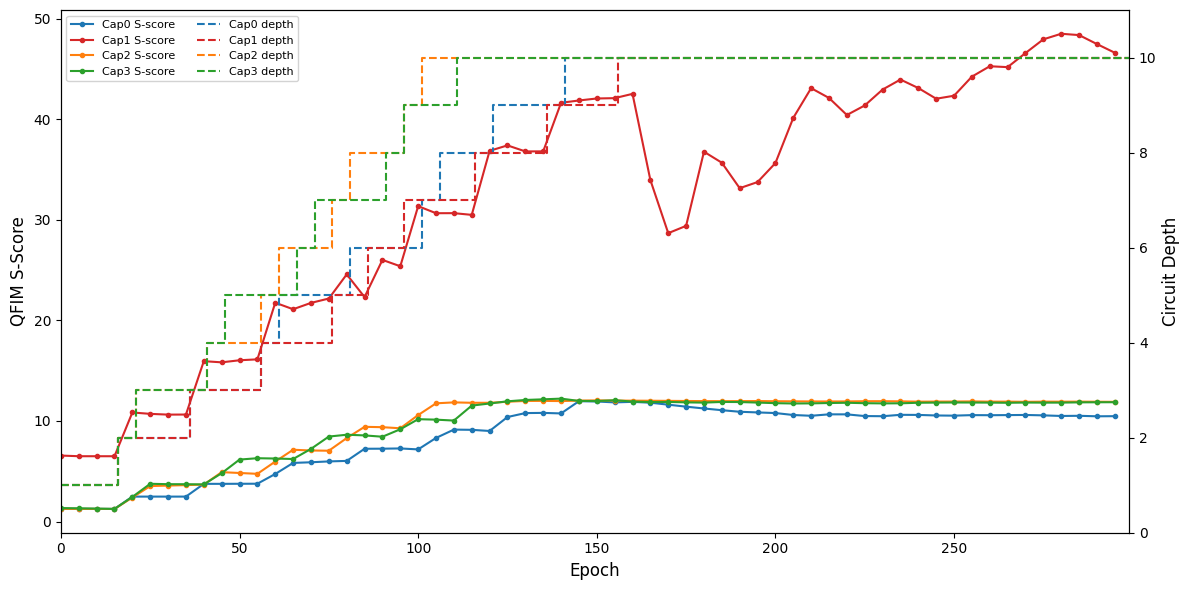

Plot saved as qfim_s_score_depth_plot.png


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ─── File paths ───────────────────────────────────────────────────────────────
S_SCORE_CSV = r"C:\Users\User\Downloads\barren pleatau mitigation\barren_plateau_output\04c_qfim_s_score_records_20260506_093246.csv"
DEPTH_CSV   = r"C:\Users\User\Downloads\barren pleatau mitigation\barren_plateau_output\04b_qfim_depth_history_20260506_093246.csv"

# ─── Load data ────────────────────────────────────────────────────────────────
ss  = pd.read_csv(S_SCORE_CSV)
dep = pd.read_csv(DEPTH_CSV)

# Filter adaptive model only
ss_adp  = ss[ss['model'] == 'adaptive'].copy()
dep_adp = dep[dep['model'] == 'adaptive'].copy()

# Pivot s_score: rows=epoch, cols=capsule
ss_pivot = ss_adp.pivot(index='epoch', columns='capsule', values='s_score')
ss_pivot.columns = [f'cap{c}' for c in ss_pivot.columns]

# Depth columns
depth_cols = ['cap0_depth', 'cap1_depth', 'cap2_depth', 'cap3_depth']

# ─── Detect growth events (any depth increase) ────────────────────────────────
growth_epochs = set()
prev = None
for _, row in dep_adp.iterrows():
    cur = tuple(row[depth_cols])
    if prev is not None and any(c > p for c, p in zip(cur, prev)):
        growth_epochs.add(int(row['epoch']))
    prev = cur

# ─── Colors ──────────────────────────────────────────────────────────────────
cap_colors = {
    'cap0': '#1f77b4',   # blue
    'cap1': '#d62728',   # red
    'cap2': '#ff7f0e',   # orange
    'cap3': '#2ca02c',   # green
}

# ─── Plot ─────────────────────────────────────────────────────────────────────
fig, ax1 = plt.subplots(figsize=(12, 6))
ax2 = ax1.twinx()



# S-score lines (solid) on ax1
for cap in ['cap0', 'cap1', 'cap2', 'cap3']:
    epochs = ss_pivot.index.values
    scores = ss_pivot[cap].values
    ax1.plot(epochs, scores,
             color=cap_colors[cap],
             marker='o', markersize=3,
             linewidth=1.5,
             label=f'{cap.capitalize()} S-score')

# Depth lines (dashed) on ax2
for i, col in enumerate(depth_cols):
    cap = f'cap{i}'
    ax2.step(dep_adp['epoch'], dep_adp[col],
             where='post',
             color=cap_colors[cap],
             linestyle='--',
             linewidth=1.5,
             label=f'{cap.capitalize()} depth')

# ─── Axes labels & limits ────────────────────────────────────────────────────
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('QFIM S-Score', fontsize=12)
ax2.set_ylabel('Circuit Depth', fontsize=12)

ax1.set_xlim(0, dep_adp['epoch'].max())
ax2.set_ylim(0, 11)


# ─── Legend ──────────────────────────────────────────────────────────────────
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(handles1 + handles2, labels1 + labels2,
           loc='upper left', fontsize=8, ncol=2,
           framealpha=0.85)

plt.tight_layout()
plt.savefig('qfim_s_score_depth_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved as qfim_s_score_depth_plot.png")

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

# ─── File path ────────────────────────────────────────────────────────────────
CSV_PATH = r"C:\Users\User\Downloads\barren pleatau mitigation\barren_plateau_output\01_gradient_variance_20260506_093246.csv"

# ─── Load ─────────────────────────────────────────────────────────────────────
df = pd.read_csv(CSV_PATH)

# ─── Model style config ───────────────────────────────────────────────────────
# সব model এ circle ('o') marker, শুধু color আলাদা
model_styles = {
    'global':   {'color': '#d62728', 'label': 'Global'},
    'qcn_cs2':  {'color': '#1f77b4', 'label': 'QCN CS-2'},
    'qcn_cs3':  {'color': '#ff7f0e', 'label': 'QCN CS-3'},
    'qcn_cs4':  {'color': '#2ca02c', 'label': 'QCN CS-4'},
    'qcn_cs6':  {'color': '#9467bd', 'label': 'QCN CS-6'},
    'qcn_cs9':  {'color': '#8c564b', 'label': 'QCN CS-9'},
}

# Bubble size scaled from grad_var_std
std_vals = df['grad_var_std'].values
std_min, std_max = std_vals.min(), std_vals.max()
bubble_sizes = 60 + 600 * (std_vals - std_min) / (std_max - std_min + 1e-30)

# ─── Plot ─────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

for model, style in model_styles.items():
    sub = df[df['model'] == model].copy()
    if sub.empty:
        continue
    idx = sub.index

    # bubble scatter — সব circle ('o')
    ax.scatter(
        sub['n_qubits'],
        sub['grad_var_mean'],
        s=bubble_sizes[idx],
        c=style['color'],
        marker='o',          # সব circle
        alpha=0.80,
        edgecolors='white',
        linewidths=0.8,
        label=style['label'],
        zorder=3,
    )
    # connecting line (কোনো horizontal reference line নয়)
    sub_sorted = sub.sort_values('n_qubits')
    ax.plot(sub_sorted['n_qubits'], sub_sorted['grad_var_mean'],
            color=style['color'], linewidth=1.2, alpha=0.50, zorder=2)

# ─── Axes ─────────────────────────────────────────────────────────────────────
ax.set_yscale('log')
ax.set_xlabel('Number of Qubits', fontsize=12)
ax.set_ylabel('Gradient Variance (mean)', fontsize=12)
ax.set_title(
    'Bubble size ∝ Gradient Variance Std Dev',
    fontsize=13, fontweight='bold'
)

ax.xaxis.set_major_locator(ticker.MultipleLocator(2))
ax.grid(True, which='both', linestyle='--', alpha=0.30)

# ─── একটিমাত্র legend — bottom left, bubble size legend নেই ──────────────────
ax.legend(
    title='Model', fontsize=9, title_fontsize=10,
    loc='lower left', framealpha=0.9
)

plt.tight_layout()
plt.savefig('bubble_gradient_variance_v2.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: bubble_gradient_variance_v2.png")

Saved: bubble_gradient_variance_v2.png


Saved → fig4_qfim_adaptive_depth.png


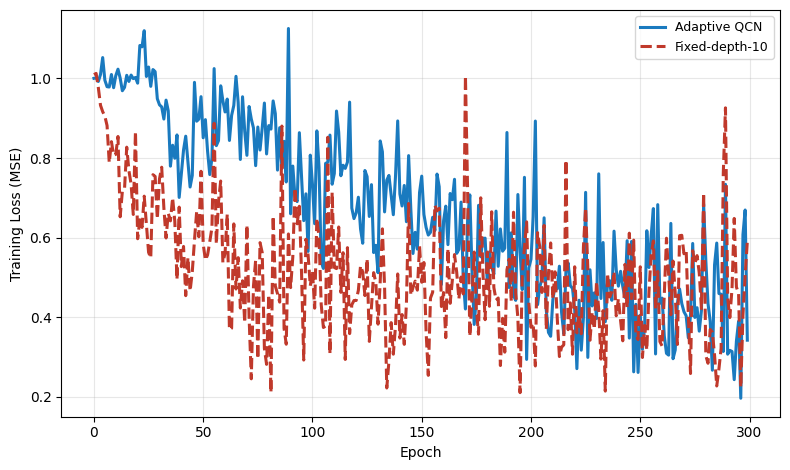

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# ── Load CSV ───────────────────────────────────────────────────────────────
CSV_PATH = r"C:\Users\User\Downloads\barren pleatau mitigation\barren_plateau_output\04a_qfim_loss_log_20260506_204443.csv"

df = pd.read_csv(CSV_PATH)

# Split by model
adaptive_df = df[df['model'] == 'adaptive'].reset_index(drop=True)
fixed_df    = df[df['model'] == 'fixed_10'].reset_index(drop=True)

# ── Config ─────────────────────────────────────────────────────────────────

mean_final_depth  = 10
EPOCHS_A = len(adaptive_df)
EPOCHS_F = len(fixed_df)

# ── Panel B: Loss Convergence ──────────────────────────────────────────────
fig, ax_l = plt.subplots(figsize=(8, 4.8))

ax_l.plot(range(EPOCHS_A), adaptive_df['loss'],
          color='#1a7abf', lw=2.2, label='Adaptive QCN')

ax_l.plot(range(EPOCHS_F), fixed_df['loss'],
          color='#c0392b', lw=2.2, ls='--',
          label=f'Fixed-depth-{mean_final_depth}')



ax_l.set_xlabel('Epoch')
ax_l.set_ylabel('Training Loss (MSE)')

ax_l.legend(fontsize=9)
ax_l.grid(True, alpha=0.30)

plt.tight_layout()
plt.savefig('fig4_qfim_adaptive_depth.png', dpi=150, bbox_inches='tight')
print("Saved → fig4_qfim_adaptive_depth.png")
plt.show()

In [18]:
"""
QCN System Architecture Diagram — matplotlib only
Run this script standalone; it saves qcn_architecture.png
"""

import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

fig, ax = plt.subplots(figsize=(16, 20))
ax.set_xlim(0, 16)
ax.set_ylim(0, 20)
ax.axis('off')
fig.patch.set_facecolor('white')

# ── Color palette ──────────────────────────────────────────────────────────
C = {
    'gray':   ('#f1efe8', '#444441'),   # fill, text
    'blue':   ('#e6f1fb', '#0c447c'),
    'teal':   ('#e1f5ee', '#085041'),
    'purple': ('#eeedfe', '#3c3489'),
    'amber':  ('#faeeda', '#633806'),
    'coral':  ('#faece7', '#712b13'),
    'green':  ('#eaf3de', '#27500a'),
    'section':('#f8f8f8', '#555555'),
}

def box(ax, x, y, w, h, label, sublabel=None, color='blue', fontsize=9):
    fill, txt = C[color]
    patch = FancyBboxPatch((x, y), w, h,
                           boxstyle="round,pad=0.05",
                           facecolor=fill, edgecolor=txt,
                           linewidth=0.8, zorder=3)
    ax.add_patch(patch)
    cy = y + h / 2 + (0.12 if sublabel else 0)
    ax.text(x + w/2, cy, label,
            ha='center', va='center', fontsize=fontsize,
            fontweight='bold', color=txt, zorder=4)
    if sublabel:
        ax.text(x + w/2, y + h/2 - 0.18, sublabel,
                ha='center', va='center', fontsize=7.5,
                color=txt, zorder=4, style='italic')

def arrow(ax, x1, y1, x2, y2, color='#888888'):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', color=color,
                                lw=1.2, connectionstyle='arc3,rad=0.0'),
                zorder=2)

def section_label(ax, x, y, text):
    ax.text(x, y, text, fontsize=8, color='#888888',
            fontstyle='italic', va='bottom')

def dashed_rect(ax, x, y, w, h, label, color='#cccccc'):
    rect = mpatches.FancyBboxPatch((x, y), w, h,
                                   boxstyle="round,pad=0.05",
                                   facecolor='#fafafa', edgecolor=color,
                                   linewidth=1.0, linestyle='--', zorder=1)
    ax.add_patch(rect)
    ax.text(x + 0.12, y + h - 0.18, label,
            fontsize=7.5, color=color, va='top', style='italic')


# ════════════════════════════════════════════════════════════════════════════
# Row 0 — Input / Config
# ════════════════════════════════════════════════════════════════════════════
section_label(ax, 0.3, 19.3, 'Input / Config')
box(ax, 4.5, 18.9, 7, 0.7,
    'Data & Hyperparameters',
    'QUBIT_RANGES · CAP_SIZES · seeds · MAX_DEPTH · LOSS_THR',
    color='gray', fontsize=9)

arrow(ax, 8.0, 18.9, 8.0, 18.15)


# ════════════════════════════════════════════════════════════════════════════
# Row 1 — Circuit Builders
# ════════════════════════════════════════════════════════════════════════════
dashed_rect(ax, 0.2, 16.8, 15.6, 1.2, 'Circuit builders')
box(ax, 0.5,  17.0, 4.5, 0.7, 'build_global_circuit()',   'RY+RZ+CNOT global entangler', color='blue')
box(ax, 5.5,  17.0, 5.0, 0.7, 'build_adaptive_qcn_circuit()', 'capsule-local Rot+CNOT+inter-cap CNOT', color='blue')
box(ax, 11.0, 17.0, 4.6, 0.7, 'cap_state() (QFIM)',       'per-cap state for metric tensor', color='blue')

arrow(ax, 8.0, 17.0, 8.0, 16.25)
arrow(ax, 3.5, 17.0, 3.5, 14.95)   # global → Sec1


# ════════════════════════════════════════════════════════════════════════════
# Row 2 — AdaptiveQCN class
# ════════════════════════════════════════════════════════════════════════════
dashed_rect(ax, 0.2, 14.4, 15.6, 1.6, 'AdaptiveQCN  (class)')

box(ax, 0.5,  14.6, 3.0, 0.7, '__init__()',         'depths · cap_params · s_window', color='teal')
box(ax, 3.8,  14.6, 3.0, 0.7, '_rebuild_params()',  'concat caps → flat params tensor', color='teal')
box(ax, 7.0,  14.6, 3.0, 0.7, 'maybe_grow()',       'ΔS < thr → depth++ · new layer', color='teal')
box(ax, 10.2, 14.6, 2.5, 0.7, 'update_params()',    'sync flat → per-cap arrays', color='teal')
box(ax, 12.9, 14.6, 2.7, 0.7, 'final_s_scores()',   'QFIM S per capsule', color='teal')

arrow(ax, 8.0, 14.4, 8.0, 13.55)


# ════════════════════════════════════════════════════════════════════════════
# Row 3 — QFIM scoring helper
# ════════════════════════════════════════════════════════════════════════════
section_label(ax, 0.3, 13.45, 'QFIM scoring')
box(ax, 3.5, 12.9, 9.0, 0.7,
    '_compute_qfim_score()',
    'metric_tensor → eigvals → d_eff · κ · S-score',
    color='purple', fontsize=9)

arrow(ax, 8.0, 12.9, 8.0, 12.15)


# ════════════════════════════════════════════════════════════════════════════
# Row 4 — 4 experiment sections (side by side)
# ════════════════════════════════════════════════════════════════════════════
section_label(ax, 0.3, 12.05, 'Experiment sections')

# Sec 1 — Gradient Variance
dashed_rect(ax, 0.2, 10.0, 3.6, 1.85, '[1] Grad Var', color='#1a7abf')
box(ax, 0.4, 11.1, 3.2, 0.6, 'grad_var_single()',  'N_SEEDS × N_STEPS grads', color='blue')
box(ax, 0.4, 10.2, 3.2, 0.7, 'gv_global / gv_caps','mean · std · norm per n', color='gray')

# Sec 2 — Entropy
dashed_rect(ax, 4.1, 10.0, 3.6, 1.85, '[2] Entropy', color='#1e8c45')
box(ax, 4.3, 11.1, 3.2, 0.6, 'entropy_global\n_at_depth()',   'density_matrix → eigvals → S', color='green')
box(ax, 4.3, 10.2, 3.2, 0.7, 'entropy_adaptive\n_qcn_at_depth()', 'Haar-random params · area/vol law', color='green')

# Sec 3 — Hessian KS
dashed_rect(ax, 8.0, 10.0, 3.6, 1.85, '[3] Hessian KS', color='#9b2dca')
box(ax, 8.2, 11.1, 3.2, 0.6, 'hessian_eigs\n_adaptive()',  'K×K finite-diff Hessian', color='purple')
box(ax, 8.2, 10.2, 3.2, 0.7, 'hessian_eigs\n_global()',    'ks_2samp → D, p-value', color='purple')

# Sec 4 — QFIM Training
dashed_rect(ax, 11.9, 10.0, 3.9, 1.85, '[4] QFIM Training', color='#e07b00')
box(ax, 12.1, 11.1, 3.5, 0.6, 'run_qfim_training()',   'adaptive vs fixed-depth', color='amber')
box(ax, 12.1, 10.2, 3.5, 0.7, 'AdamOptimizer loop',    'QFIM_INTERVAL growth · early stop', color='amber')

# arrows from AdaptiveQCN to each section
for tx in [2.0, 6.0, 9.8, 13.85]:
    arrow(ax, 8.0, 12.9, tx, 11.85, color='#aaaaaa')

arrow(ax, 2.0,  10.0, 2.0,  9.3)
arrow(ax, 6.0,  10.0, 6.0,  9.3)
arrow(ax, 9.8,  10.0, 9.8,  9.3)
arrow(ax, 13.85,10.0, 13.85, 9.3)


# ════════════════════════════════════════════════════════════════════════════
# Row 5 — CSV outputs
# ════════════════════════════════════════════════════════════════════════════
section_label(ax, 0.3, 9.2, 'CSV outputs')
csvs = [
    (0.2,  '01_gradient\n_variance.csv'),
    (4.1,  '02_entanglement\n_entropy.csv'),
    (8.0,  '03_hessian\n_ks_stat.csv'),
    (11.9, '04a–e_qfim\n_*.csv'),
]
for x, lbl in csvs:
    box(ax, x, 8.5, 3.6, 0.65, lbl, color='gray', fontsize=8)


# ════════════════════════════════════════════════════════════════════════════
# Row 6 — Smoothing helper
# ════════════════════════════════════════════════════════════════════════════
section_label(ax, 0.3, 8.35, 'Smoothing helper')
box(ax, 4.5, 7.75, 7.0, 0.5,
    'smooth_loss() / smooth_epochs()   —   moving average window=15',
    color='gray', fontsize=8)

arrow(ax, 8.0, 7.75, 8.0, 7.1)


# ════════════════════════════════════════════════════════════════════════════
# Row 7 — Figure generation
# ════════════════════════════════════════════════════════════════════════════
section_label(ax, 0.3, 7.0, 'Figure generation  [5/5]')

figs = [
    (0.2,  'fig1\nbubble GV',        'coral'),
    (3.4,  'fig2\nentropy',          'green'),
    (6.6,  'fig3a\nKS line',         'purple'),
    (9.8,  'fig3b\nKS heatmap',      'purple'),
    (12.0, 'fig4a\ndepth vs S',      'amber'),
    (14.2, 'fig4b\nloss curve',      'amber'),
]
for x, lbl, col in figs:
    box(ax, x, 6.0, 1.9, 0.85, lbl, color=col, fontsize=7.5)
    arrow(ax, x+0.95, 6.0, x+0.95, 5.3, color='#aaaaaa')


# ════════════════════════════════════════════════════════════════════════════
# Row 8 — PNG outputs
# ════════════════════════════════════════════════════════════════════════════
section_label(ax, 0.3, 5.2, 'PNG outputs  →  BASE_DIR')
box(ax, 0.3, 4.4, 15.4, 0.65,
    'fig1_gradient_variance_bubble.png   fig2_entanglement_entropy.png   '
    'fig3a_hessian_ks_line.png   fig3b_hessian_ks_heatmap.png   '
    'fig4a_depth_vs_sscore.png   fig4b_loss_convergence.png',
    color='gray', fontsize=7.5)


# ════════════════════════════════════════════════════════════════════════════
# Row 9 — Summary CSV
# ════════════════════════════════════════════════════════════════════════════
section_label(ax, 0.3, 4.3, 'Summary')
box(ax, 3.5, 3.5, 9.0, 0.65,
    '00_summary.csv   +   pennylane_timing.csv',
    color='gray', fontsize=8.5)


# ════════════════════════════════════════════════════════════════════════════
# Title
# ════════════════════════════════════════════════════════════════════════════

plt.tight_layout(pad=0.5)
plt.savefig('qcn_architecture.png', dpi=180, bbox_inches='tight',
            facecolor='white', edgecolor='none')
print('Saved → qcn_architecture.png')

Saved → qcn_architecture.png


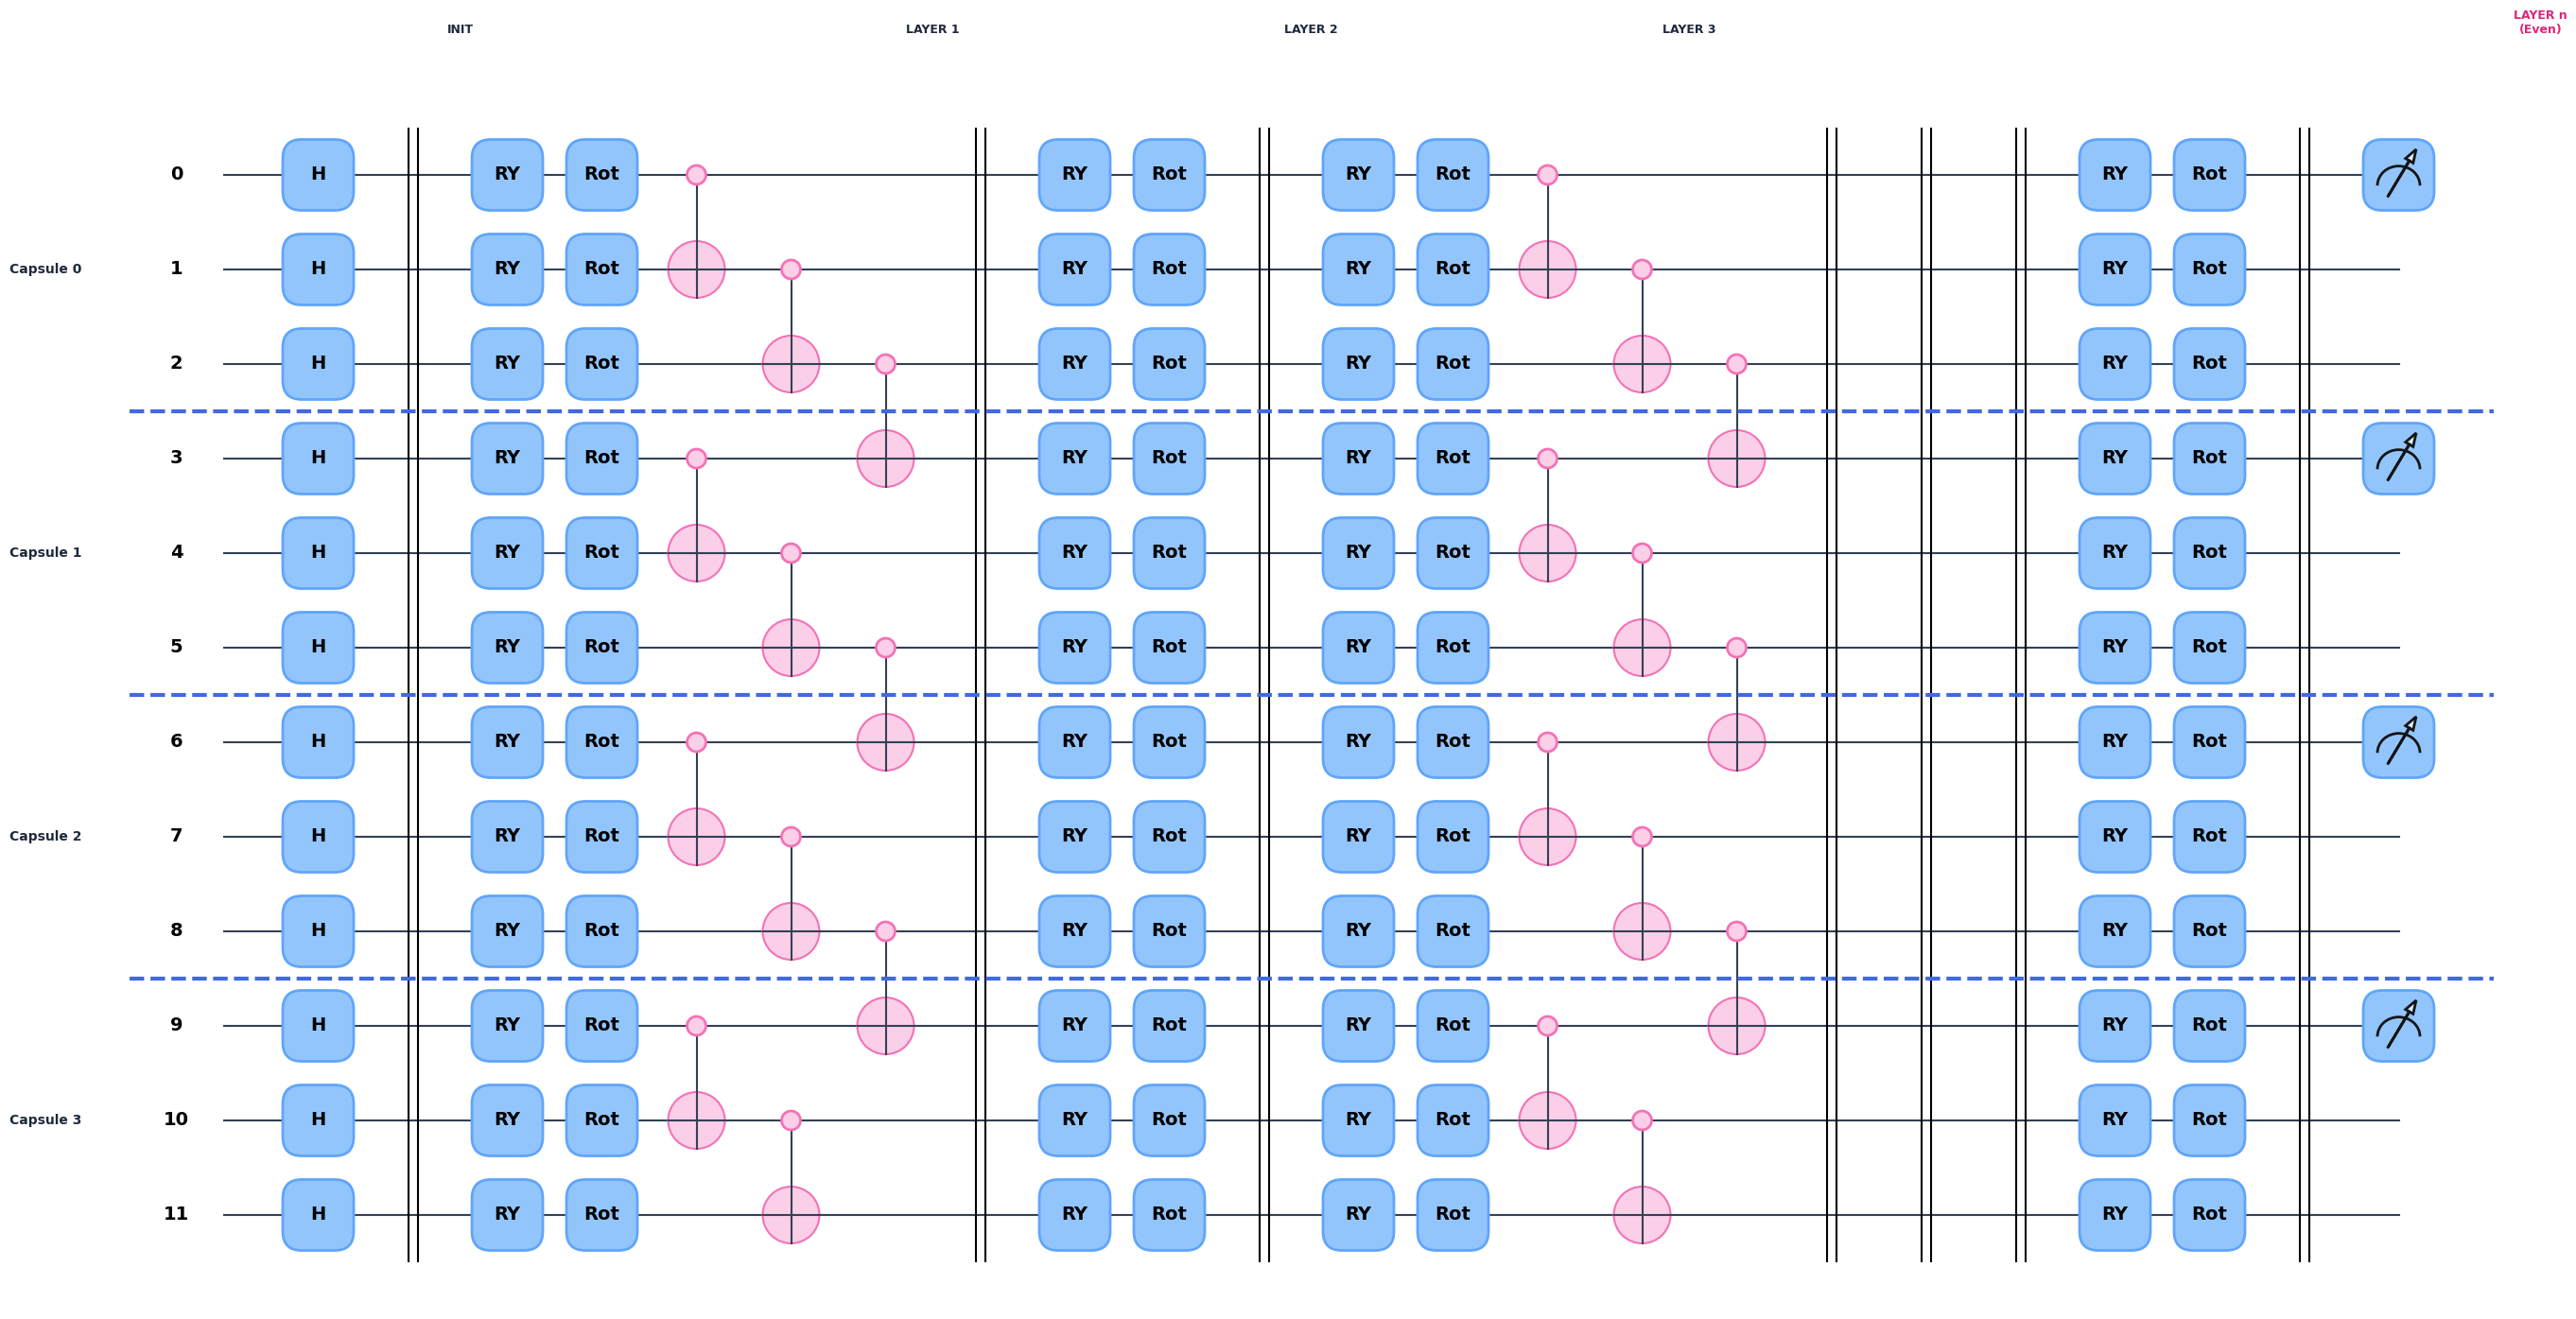

In [39]:
import pennylane as qml
from pennylane import numpy as np
import matplotlib.pyplot as plt

# backend fix
%matplotlib inline 

def build_final_architecture(n=12, n_caps=4, cap_size=3):
    dev = qml.device("default.qubit", wires=n)

    @qml.qnode(dev)
    def circuit(x, params):
        # --- INIT LAYER: strictly only Hadamard as per diagram ---
        for i in range(n):
            qml.Hadamard(wires=i)
        qml.Barrier(wires=range(n))

        # --- LAYERS 1, 2, 3 ---
        for l in range(1, 4):
            for i in range(n):
                qml.RY(x[i], wires=i)
                qml.Rot(params[l, i, 0], params[l, i, 1], params[l, i, 2], wires=i)
            
            # CNOT entanglement logic as per architecture
            if l % 2 != 0: 
                for c in range(n_caps):
                    w = list(range(c * cap_size, (c + 1) * cap_size))
                    for j in range(len(w) - 1): qml.CNOT(wires=[w[j], w[j + 1]])
                for c in range(n_caps - 1):
                    qml.CNOT(wires=[(c + 1) * cap_size - 1, (c + 1) * cap_size])
            qml.Barrier(wires=range(n))

        # --- GAP AREA (Double Barrier for partition) ---
        qml.Barrier(wires=range(n)) 
        qml.Barrier(wires=range(n)) 

        # --- LAYER N (Even/Final Layer) ---
        for i in range(n):
            qml.RY(x[i], wires=i)
            qml.Rot(params[-1, i, 0], params[-1, i, 1], params[-1, i, 2], wires=i)
        qml.Barrier(wires=range(n))
        
        return [qml.expval(qml.PauliZ(i*cap_size)) for i in range(n_caps)]

    return circuit

# Drawing Configuration
n, n_caps, cap_size = 12, 4, 3
p_data = np.random.randn(5, n, 3)

fig, ax = qml.draw_mpl(build_final_architecture(), style="pennylane")(np.ones(n), p_data)
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

# 1. Gate Styling (Blue for Gates, Pink for CNOT)
for patch in ax.patches:
    txt = str(patch)
    if 'Circle' in txt:
        patch.set_facecolor('#fbcfe8')
        patch.set_edgecolor('#f472b6')
    elif 'FancyBboxPatch' in txt or 'Rectangle' in txt:
        patch.set_facecolor('#93c5fd')
        patch.set_edgecolor('#60a5fa')

# 2. Removing Horizontal Wires in the Gap (Layer 3 to Layer n)
gap_start, gap_end = 18.2, 21.8

for line in ax.lines:
    x = np.array(line.get_xdata())
    y = np.array(line.get_ydata())
    
    # Hide horizontal wires and any middle barrier lines in the gap
    if x.size > 1:
        if np.any((x > gap_start) & (x < gap_end)) and np.isclose(y[0], y[1]):
            line.set_visible(False) 
        elif np.all((x >= gap_start) & (x <= gap_end)):
            line.set_visible(False)

    if line.get_visible():
        if line.get_marker() == 'o':
            line.set_markerfacecolor('#f472b6')
            line.set_markeredgecolor('#f472b6')
        else:
            line.set_color('#334155')

# 3. Vertical Dots (Ellipsis) exactly in the gap
for i in range(n):
    ax.text((gap_start + gap_end)/2, i, "...", fontsize=20, 
            weight='bold', ha='center', va='center', color='#cbd5e1', rotation=90)

# 4. Royal Blue Bold Capsule Partitions (#4169E1)
for i in range(n_caps - 1):
    y_sep = (i + 1) * cap_size - 0.5
    ax.axhline(y_sep, color='#4169E1', linestyle='--', linewidth=3.0, zorder=10)

# 5. Labeling matching your Architecture
label_data = [(1.5, "INIT"), (6.5, "LAYER 1"), (10.5, "LAYER 2"), (14.5, "LAYER 3"), (23.5, "LAYER n\n(Even)")]
for pos, txt in label_data:
    color = '#db2777' if 'n' in txt else '#1e293b'
    ax.text(pos, -1.5, txt, weight='bold', fontsize=9, ha='center', color=color)

for i in range(n_caps):
    ax.text(-2.5, i * cap_size + 1, f"Capsule {i}", 
            fontsize=10, weight='bold', color='#1e293b', va='center', ha='right')

plt.show()